
[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\_msi_\anaconda3\python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\_msi_\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Accuracy: 0.9211356466876972


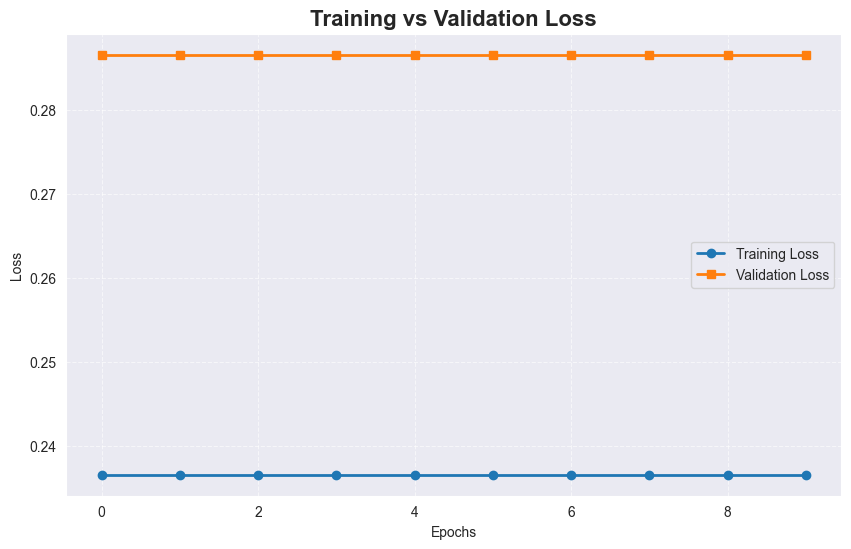

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
from nltk.corpus import stopwords

# Load dataset
df = pd.read_csv('fake_or_real_news.csv')

# Basic preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['text'] = df['text'].apply(clean_text)

# Convert labels (fake=0, real=1)
df['label'] = df['label'].map({'FAKE':0, 'REAL':1})

X = df['text']
y = df['label']

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)

# Model training with manual loss tracking
model = LogisticRegression(max_iter=1000)

train_loss = []
val_loss = []

for i in range(10):
    model.fit(X_train, y_train)
    
    train_pred = model.predict_proba(X_train)
    val_pred = model.predict_proba(X_val)
    
    train_loss.append(-np.mean(np.log(train_pred[np.arange(len(y_train)), y_train])))
    val_loss.append(-np.mean(np.log(val_pred[np.arange(len(y_val)), y_val])))

# Evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot (Lab Requirement)
plt.figure(figsize=(10,6))
sns.set_style("darkgrid")

plt.plot(train_loss, marker='o', linewidth=2, label='Training Loss')
plt.plot(val_loss, marker='s', linewidth=2, label='Validation Loss')

plt.title('Training vs Validation Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()